In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, _affinity_propagation

In [3]:
def fillMissingData(X, column):
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(missing_values=np.nan, strategy="median")
    X[:, column:column + 1] = imputer.fit_transform(X[:, column:column + 1])
    return X


In [4]:
CAMINHO = "C:\\Users\\Nitro\\Desktop\\Redes-Neurais\\svbr.csv"

In [5]:
df = pd.read_csv(CAMINHO, delimiter=';')
df.head()

,Canal,Inscritos,Visualizações
0,Site Arqueologia Egípcia,13438.0,406590
1,Terra Negra,35241.0,868235
2,Frank Jaava,31680.0,2856508
3,Dispersciência,25100.0,150000
4,Olá Ciência,32788.0,1575456


In [6]:
#pré-processamento
df_numpy = fillMissingData(df.to_numpy(), 1)
df_numpy[:, 1] = df_numpy[:, 1].astype("int")
df_numpy = fillMissingData(df_numpy, 2)
df_numpy[:, 2] = df_numpy[:, 2].astype("int")

#atualiza peixe babel
df.at[28, "Inscritos"] = df_numpy[28][1]
df.at[28, "Visualizações"] = df_numpy[28][2]

#converte inscritos e visualizações para inteiro
df.Inscritos = df.Inscritos.astype("int")
df.Visualizações = df.Visualizações.astype("int")

X = pd.DataFrame({"Inscritos": df_numpy[:, 1], "Visualizações": df_numpy[:, 2]})
X.head()

,Inscritos,Visualizações
0,13438,406590
1,35241,868235
2,31680,2856508
3,25100,150000
4,32788,1575456


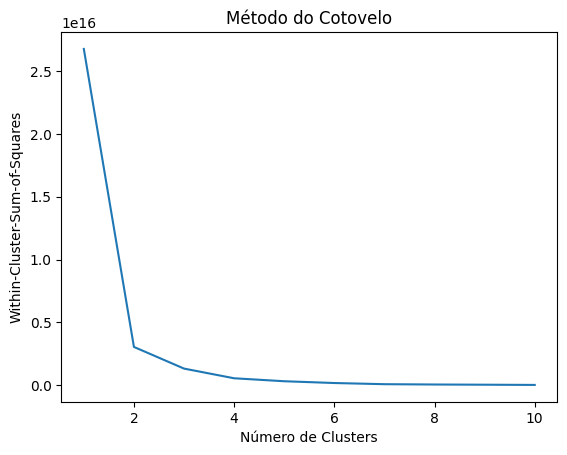

In [7]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters= i, init='k-means++', max_iter=300, n_init= 10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters")
plt.ylabel("Within-Cluster-Sum-of-Squares")
plt.show()

K = 2

In [8]:
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init= 10)
clusters = kmeans.fit_predict(X)
clusters

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0], dtype=int32)

In [9]:
df["Cluster"] = clusters

In [10]:
boolArray = df["Cluster"] == 0
df[boolArray]

,Canal,Inscritos,Visualizações,Cluster
0,Site Arqueologia Egípcia,13438,406590,0
1,Terra Negra,35241,868235,0
2,Frank Jaava,31680,2856508,0
3,Dispersciência,25100,150000,0
4,Olá Ciência,32788,1575456,0
5,A matemaníaca por Julia Jaccoud,65453,1667892,0
6,Delta T - Os super lentos,12000,171361,0
7,Bláblálogia,161951,11027386,0
8,Efarsas,78876,6226235,0
9,Minuto da Terra,274196,30166457,0


In [11]:
boolArray = df["Cluster"] == 1
df[boolArray]

,Canal,Inscritos,Visualizações,Cluster
18,Matemática Rio com Prof Rafael Procópio,1423056,93036517,1
32,Canal do Pirula,752573,76462787,1
39,Schwarza - Poligonautas,860493,118741623,1


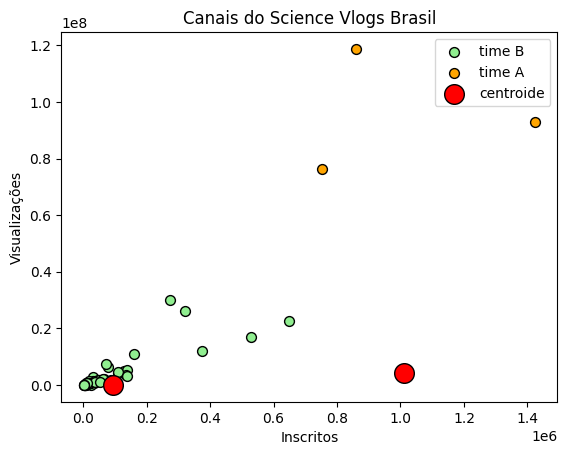

In [12]:
x = X.to_numpy()

plt.scatter(
    x[clusters == 0, 0], x[clusters == 0, 1],
    s=50, c='lightgreen',
    edgecolors='black',
    label='time B'
)

plt.scatter(
    x[clusters == 1, 0], x[clusters == 1, 1],
    s=50, c='orange',
    edgecolors='black',
    label='time A'
)

# plot the centroids
plt.scatter(
    kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:1],
    s=200, c='red', edgecolors='black',
    label='centroide'
)
plt.title("Canais do Science Vlogs Brasil")
plt.xlabel("Inscritos")
plt.ylabel("Visualizações")

plt.legend()
plt.show()

K = 3

In [13]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init= 10)
clusters = kmeans.fit_predict(X)
clusters

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 0, 2, 2, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0], dtype=int32)

In [14]:
df["Cluster2"] = clusters

In [15]:
boolClusters = df["Cluster2"] == 0
df[boolClusters]

,Canal,Inscritos,Visualizações,Cluster,Cluster2
0,Site Arqueologia Egípcia,13438,406590,0,0
1,Terra Negra,35241,868235,0,0
2,Frank Jaava,31680,2856508,0,0
3,Dispersciência,25100,150000,0,0
4,Olá Ciência,32788,1575456,0,0
5,A matemaníaca por Julia Jaccoud,65453,1667892,0,0
6,Delta T - Os super lentos,12000,171361,0,0
7,Bláblálogia,161951,11027386,0,0
8,Efarsas,78876,6226235,0,0
10,Canal Cura Quântica,13148,250020,0,0


In [16]:
boolClusters = df["Cluster2"] == 1
df[boolClusters]

,Canal,Inscritos,Visualizações,Cluster,Cluster2
18,Matemática Rio com Prof Rafael Procópio,1423056,93036517,1,1
32,Canal do Pirula,752573,76462787,1,1
39,Schwarza - Poligonautas,860493,118741623,1,1


In [17]:
boolClusters = df["Cluster2"] == 2
df[boolClusters]

,Canal,Inscritos,Visualizações,Cluster,Cluster2
9,Minuto da Terra,274196,30166457,0,2
23,Minutos Psíquicos,648892,22555134,0,2
29,SpaceToday,321068,26277335,0,2
30,Ciência todo dia,528761,16969332,0,2


In [18]:
df = df.loc[:, ["Canal", "Inscritos", "Visualizações", "Cluster2"]]

In [19]:
df

,Canal,Inscritos,Visualizações,Cluster2
0,Site Arqueologia Egípcia,13438,406590,0
1,Terra Negra,35241,868235,0
2,Frank Jaava,31680,2856508,0
3,Dispersciência,25100,150000,0
4,Olá Ciência,32788,1575456,0
5,A matemaníaca por Julia Jaccoud,65453,1667892,0
6,Delta T - Os super lentos,12000,171361,0
7,Bláblálogia,161951,11027386,0
8,Efarsas,78876,6226235,0
9,Minuto da Terra,274196,30166457,2


Clusterização Hierárquica |
Dendrograma

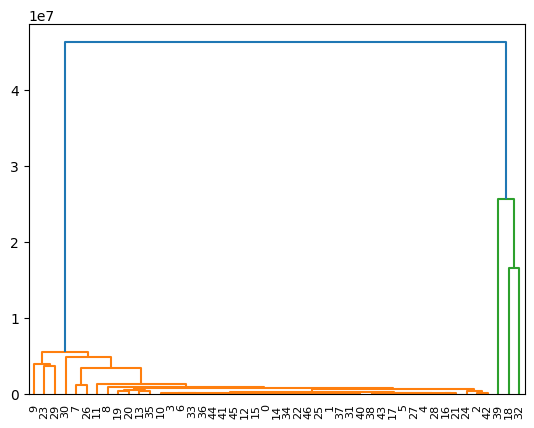

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage

#linkage realiza clusterização hierárquica a fim de se construir um dendrograma
dendrogram(linkage(x))
plt.show()

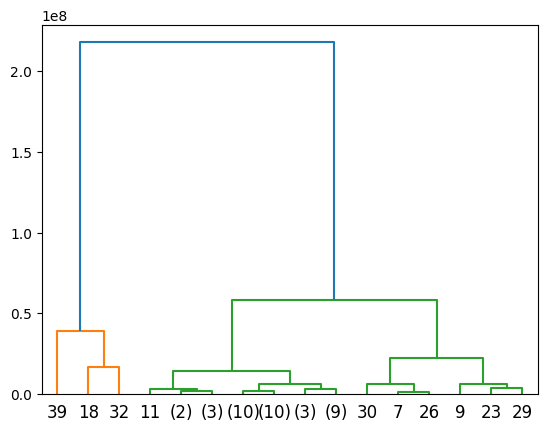

In [21]:
dendrogram(linkage(x, "ward"), truncate_mode='level', p=4)
plt.show()

Algorítmo de Clusterização Hierárquica

In [26]:
from sklearn.cluster import AgglomerativeClustering

hc_model = AgglomerativeClustering(metric="euclidean", linkage="ward")
clusters = hc_model.fit_predict(x)

df["Cluster"] = clusters
df.head()

,Canal,Inscritos,Visualizações,Cluster2,Cluster
0,Site Arqueologia Egípcia,13438,406590,0,0
1,Terra Negra,35241,868235,0,0
2,Frank Jaava,31680,2856508,0,0
3,Dispersciência,25100,150000,0,0
4,Olá Ciência,32788,1575456,0,0


In [27]:
boolArray = df["Cluster"] == 1
df[boolArray]

,Canal,Inscritos,Visualizações,Cluster2,Cluster
18,Matemática Rio com Prof Rafael Procópio,1423056,93036517,1,1
32,Canal do Pirula,752573,76462787,1,1
39,Schwarza - Poligonautas,860493,118741623,1,1


In [28]:
hc_model

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",2
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


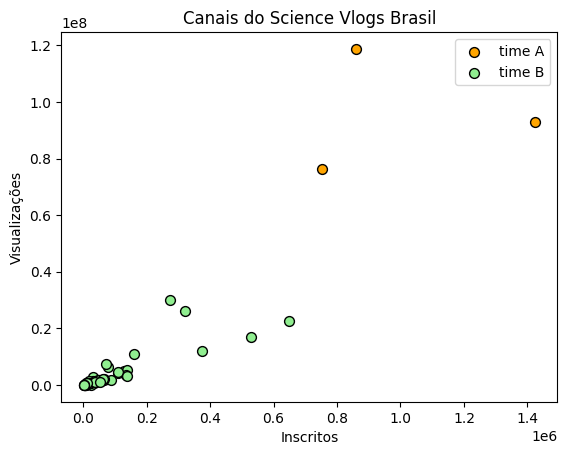

In [29]:
x = X.to_numpy()

plt.scatter(
    x[clusters == 1, 0], x[clusters == 1, 1],
    s = 50, c='orange',
    edgecolors='black',
    label='time A'
)

plt.scatter(
    x[clusters == 0, 0], x[clusters == 0, 1],
    s = 50, c='lightgreen',
    edgecolors='black',
    label='time B'
)

plt.title("Canais do Science Vlogs Brasil")
plt.xlabel("Inscritos")
plt.ylabel("Visualizações")

plt.legend()
plt.show()

In [30]:

#https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html
#https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering
#https://towardsdatascience.com/hierarchical-clustering-explained-e58d2f936323
#https://pythonprogramming.net/hierarchical-clustering-machine-learning-python-scikit-learn/
#https://joernhees.de/blog/2015/08/26/scipy-hierarchical-clustering-and-dendrogram-tutorial/